# 05 - Signal Profile Explorer

**Purpose:** Interactively explore signal quality profiles produced by `scripts/06_signal_profiles.py`.

Drill into one signal or one category at a time using DuckDB - no need to load 40 GB into memory.

**Requires:** `reports/signal_quality_profiles.csv`
Run first: `python scripts/06_signal_profiles.py --threads 6`  (60-120 min)

**How to use:**
- Change `CATEGORY` in Section 3 and re-run that cell to browse a signal group
- Change `SIGNAL` in Section 4 and re-run to deep-dive any individual signal
- Change `COMPARE_SIGNALS` in Section 5 to overlay multiple signals on one chart


In [2]:
import sys
import warnings
warnings.filterwarnings("ignore")
from pathlib import Path

import duckdb
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns

PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(PROJECT_ROOT / "src"))

from zoro_eda.config import load_config
from zoro_eda.paths import resolve_paths

cfg   = load_config()
paths = resolve_paths(cfg=cfg)

sns.set_theme(style="whitegrid", palette="tab10")
print(f"Project root: {paths.root}")
print(f"Raw data:     {paths.raw_data}")
print(f"Reports:      {paths.reports}")


Project root: C:\Users\dellg\OneDrive\Documents\ZE
Raw data:     C:\Users\dellg\OneDrive\Documents\ZE\data
Reports:      C:\Users\dellg\OneDrive\Documents\ZE\reports


In [3]:
profiles_path = paths.reports / "signal_quality_profiles.csv"

if not profiles_path.exists():
    print("ERROR: signal_quality_profiles.csv not found.")
    print("Run:  python scripts/06_signal_profiles.py --threads 6")
    print("Expected runtime: 60-120 minutes on 40 GB.")
    raise FileNotFoundError(profiles_path)

profiles = pd.read_csv(profiles_path)
ok = profiles[profiles["notes"] == "ok"].copy()
print(f"Loaded {len(profiles)} signals  |  {len(ok)} profiled successfully")
print(f"Categories: {ok['category'].nunique()}")
print()
print(ok[["signal_name", "category", "row_count", "gap_ratio", "outlier_count"]].head(10).to_string(index=False))


Loaded 230 signals  |  215 profiled successfully
Categories: 48

                signal_name       category  row_count  gap_ratio  outlier_count
dintVolGasVerbrauchBhkwImp1        chp_gas      20605     0.2072              0
dintVolGasVerbrauchBhkwImp2        chp_gas      20592     0.2077              0
     greal_Administrator_HT  control_param         42     1.0000              0
        greal_AZ_WP_Energie      hp_energy     302314     0.9444            434
  greal_BatterieLadeZustand    battery_soc    4565654     0.1658          37946
          greal_E__WMZ_BHKW thermal_energy    4501221     0.1675         297699
         greal_E__WMZ_WWout thermal_energy    4501221     0.1675            698
     greal_E_BatterieAbgabe battery_energy    4501562     0.1675              0
      greal_E_BatterieLaden battery_energy    4501562     0.1675              0
              greal_E_bhkw1     chp_energy    4501169     0.1676             11


## 1. Dataset-wide quality overview

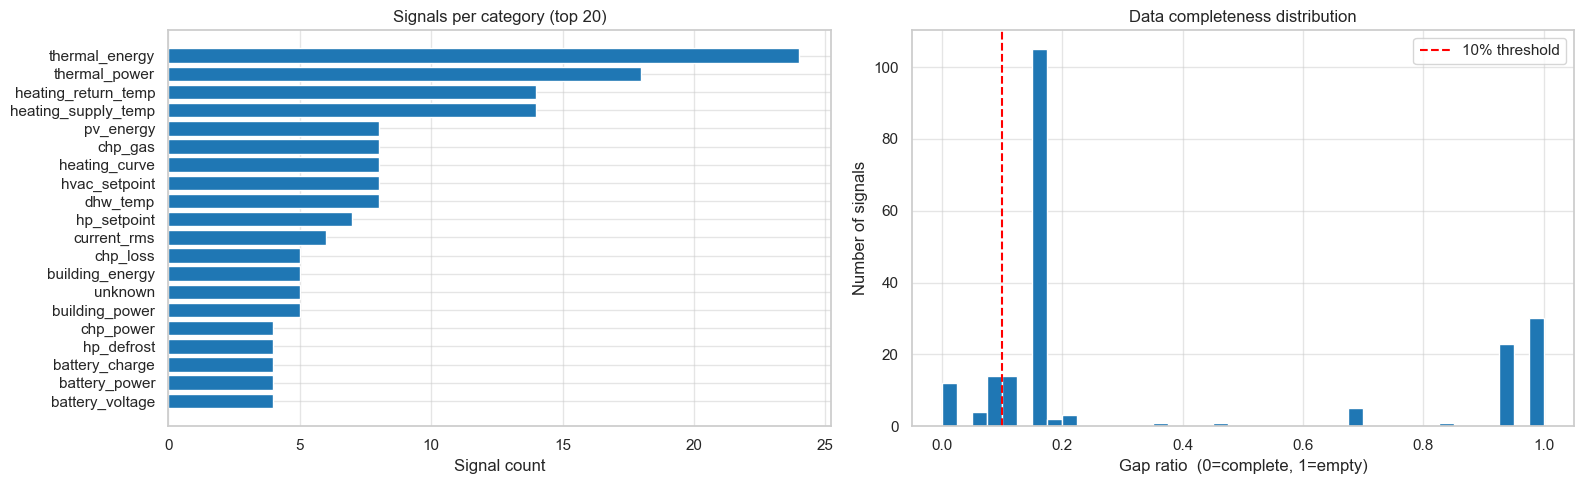

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Signal count by category
cat_counts = ok["category"].value_counts().head(20)
axes[0].barh(cat_counts.index[::-1], cat_counts.values[::-1])
axes[0].set_xlabel("Signal count")
axes[0].set_title("Signals per category (top 20)")

# Gap ratio distribution
axes[1].hist(ok["gap_ratio"], bins=40, edgecolor="white")
axes[1].axvline(0.10, color="red", linestyle="--", label="10% threshold")
axes[1].set_xlabel("Gap ratio  (0=complete, 1=empty)")
axes[1].set_ylabel("Number of signals")
axes[1].set_title("Data completeness distribution")
axes[1].legend()

plt.tight_layout()
plt.savefig(paths.plots / "05_quality_overview.png", dpi=150, bbox_inches="tight")
plt.show()


## 2. Problem signals flagged

In [5]:
high_gap      = ok[ok["gap_ratio"] > 0.10].sort_values("gap_ratio", ascending=False)
high_outliers = ok[ok["outlier_count"] > 5000].sort_values("outlier_count", ascending=False)
has_nulls     = ok[ok["null_count"] > 0]

print(f"=== High gap (>10%): {len(high_gap)} signals ===")
if len(high_gap):
    print(high_gap[["signal_name", "category", "gap_ratio", "row_count", "duration_days"]].to_string(index=False))

print(f"\n=== High outlier count (>5000): {len(high_outliers)} signals ===")
if len(high_outliers):
    print(high_outliers[["signal_name", "category", "outlier_count", "val_min", "val_max"]].to_string(index=False))

print(f"\n=== Has null values: {len(has_nulls)} signals ===")
if len(has_nulls):
    print(has_nulls[["signal_name", "null_count"]].to_string(index=False))


=== High gap (>10%): 185 signals ===
                     signal_name            category  gap_ratio  row_count  duration_days
          greal_Administrator_HT       control_param     1.0000         42        1152.79
            greal_Nachtabsenkung       night_setback     1.0000         42        1152.79
          greal_JalousienMaxWind       control_param     1.0000         37        1146.94
         V_real_NachtabsenkungY4       night_setback     1.0000         39        1068.29
                     V_realAZmax         hp_setpoint     1.0000         40        1152.96
          V_real_minVorlaufTempK       heating_curve     1.0000         45        1152.96
           V_real_minVorlaufTemp       heating_curve     1.0000         43        1152.96
                  V_real_minATY4       hvac_setpoint     1.0000         40        1152.96
             V_realSollTempAZmax         hp_setpoint     1.0000         40        1152.96
           V_real_maxVorlaufTemp       heating_curve     1.0000

## 3. Browse by category

Change `CATEGORY` below and re-run this cell to explore any signal group.

Available examples: `hp_defrost`, `hp_energy`, `thermal_energy`, `battery_soc`,
`outdoor_temp`, `pv_energy`, `heating_curve`, `hp_setpoint`, `battery_voltage`


Category 'hp_defrost' -- 4 signals

                  signal_name  row_count  val_min  val_max    val_mean     val_std       p50  gap_ratio  duration_days
V_real_AbtauTemperaturBetrieb         47      0.0     10.0    5.234043    3.642818    3.0000     1.0000        1152.79
            greal_WP1AbtauSek     302312      0.0    511.0  510.988168    2.458883  511.0000     0.9444        1259.68
            greal_WP2AbtauSek     302312      0.0  11535.0 1178.610641 1653.187977  298.0000     0.9444        1259.68
            greal_WP3AbtauSek     302312      0.0  10777.0 2246.794851 2840.219530 1075.6724     0.9444        1259.68


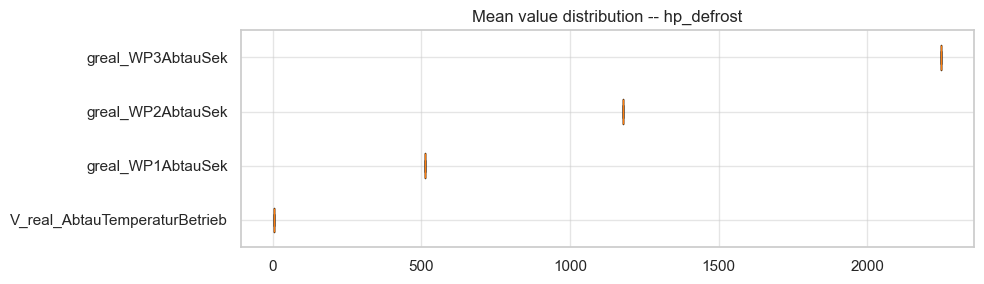

In [6]:
# -- Change this to explore a different category --
CATEGORY = "hp_defrost"
# --------------------------------------------------

subset = ok[ok["category"] == CATEGORY].sort_values("signal_name")

if subset.empty:
    print(f"No signals found for category: {CATEGORY!r}")
    print(f"Available categories: {sorted(ok['category'].unique())}")
else:
    print(f"Category '{CATEGORY}' -- {len(subset)} signals\n")
    cols = ["signal_name", "row_count", "val_min", "val_max",
            "val_mean", "val_std", "p50", "gap_ratio", "duration_days"]
    print(subset[cols].to_string(index=False))

    if len(subset) > 1:
        fig, ax = plt.subplots(figsize=(10, max(3, len(subset) * 0.4)))
        ax.boxplot(
            [ok[ok["signal_name"] == sig]["val_mean"].values for sig in subset["signal_name"]],
            labels=subset["signal_name"].tolist(),
            vert=False,
        )
        ax.set_title(f"Mean value distribution -- {CATEGORY}")
        plt.tight_layout()
        plt.show()


## 4. Deep-dive one signal

Change `SIGNAL` below and re-run. DuckDB reads the full raw CSV directly -- returns hourly means in seconds.


Signal:   greal_WP1AbtauSek
Category: hp_defrost  |  Rows: 302,312  |  Gap: 94.4%
Range:    0.0 to 511.0  |  Mean: 510.988  |  Std: 2.459
Coverage: 2022-12-14 16:40:41+02:00 to 2026-05-27 10:03:05+03:00  (1260 days)



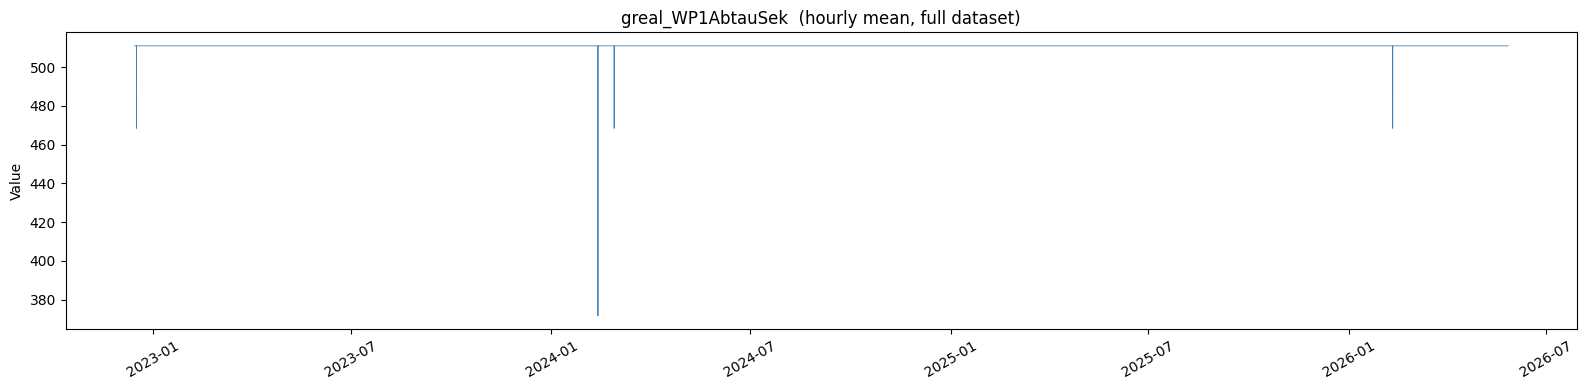

Saved: C:\Users\dellg\OneDrive\Documents\ZE\reports\plots\05_deep_dive_greal_WP1AbtauSek.png


In [8]:
# -- Change this to deep-dive any signal --
SIGNAL = "greal_WP1AbtauSek"
# ------------------------------------------

csv_path = paths.raw_data / f"{SIGNAL}.csv"

if not csv_path.exists():
    print(f"File not found: {csv_path}")
else:
    meta = ok[ok["signal_name"] == SIGNAL]
    if not meta.empty:
        m = meta.iloc[0]
        print(f"Signal:   {SIGNAL}")
        print(f"Category: {m['category']}  |  Rows: {m['row_count']:,}  |  Gap: {m['gap_ratio']:.1%}")
        print(f"Range:    {m['val_min']} to {m['val_max']}  |  Mean: {m['val_mean']:.3f}  |  Std: {m['val_std']:.3f}")
        print(f"Coverage: {m['start_time']} to {m['end_time']}  ({m['duration_days']:.0f} days)\n")

    path_str = csv_path.as_posix()
    df = duckdb.sql(f'''
        SELECT
            DATE_TRUNC('hour', TRY_CAST(_time AS TIMESTAMPTZ)) AS hour_utc,
            AVG(TRY_CAST(_value AS DOUBLE))                     AS value
        FROM read_csv(
            '{path_str}',
            delim=';', header=true, ignore_errors=true
        )
        WHERE TRY_CAST(_value AS DOUBLE) IS NOT NULL
        GROUP BY 1 ORDER BY 1
    ''').df()

    df["hour_utc"] = pd.to_datetime(df["hour_utc"], utc=True)

    fig, ax = plt.subplots(figsize=(16, 4))
    ax.plot(df["hour_utc"], df["value"], linewidth=0.6, color="steelblue")
    ax.set_title(f"{SIGNAL}  (hourly mean, full dataset)")
    ax.set_ylabel("Value")
    ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y-%m"))
    plt.xticks(rotation=30)
    plt.tight_layout()
    out = paths.plots / f"05_deep_dive_{SIGNAL}.png"
    plt.savefig(out, dpi=150, bbox_inches="tight")
    plt.show()
    print(f"Saved: {out}")

## 5. Compare signals within a category

Change `COMPARE_SIGNALS` to overlay related signals. Useful for WP1/WP2/WP3 or battery clusters 1-4.


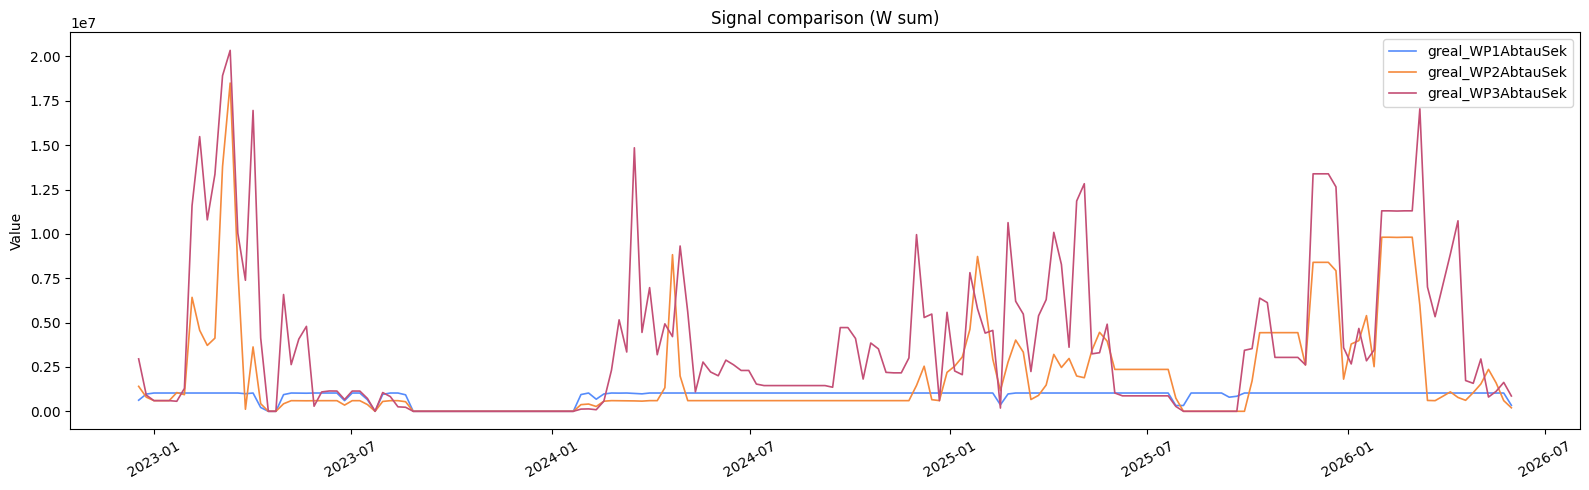

In [9]:
# -- Change these to compare signals --
COMPARE_SIGNALS = [
    "greal_WP1AbtauSek",
    "greal_WP2AbtauSek",
    "greal_WP3AbtauSek",
]
RESAMPLE_FREQ = "W"   # "D"=daily, "W"=weekly, "ME"=monthly
AGG_FUNC      = "sum" # "mean" or "sum"
# --------------------------------------

COLORS = plt.rcParams["axes.prop_cycle"].by_key()["color"]
fig, ax = plt.subplots(figsize=(16, 5))

for i, sig in enumerate(COMPARE_SIGNALS):
    csv_path = paths.raw_data / f"{sig}.csv"
    if not csv_path.exists():
        print(f"  Missing: {csv_path.name}")
        continue

    path_str = csv_path.as_posix()
    df = duckdb.sql(f'''
        SELECT
            DATE_TRUNC('hour', TRY_CAST(_time AS TIMESTAMPTZ)) AS hour_utc,
            SUM(TRY_CAST(_value AS DOUBLE))                     AS value
        FROM read_csv(
            '{path_str}',
            delim=';', header=true, ignore_errors=true
        )
        WHERE TRY_CAST(_value AS DOUBLE) IS NOT NULL
        GROUP BY 1 ORDER BY 1
    ''').df()

    if df.empty:
        continue

    df["hour_utc"] = pd.to_datetime(df["hour_utc"], utc=True)
    series = df.set_index("hour_utc")["value"]
    resampled = series.resample(RESAMPLE_FREQ).sum() if AGG_FUNC == "sum" else series.resample(RESAMPLE_FREQ).mean()
    ax.plot(resampled.index, resampled.values, label=sig, color=COLORS[i % len(COLORS)], linewidth=1.2)

ax.set_title(f"Signal comparison ({RESAMPLE_FREQ} {AGG_FUNC})")
ax.set_ylabel("Value")
ax.legend()
ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y-%m"))
plt.xticks(rotation=30)
plt.tight_layout()
plt.savefig(paths.plots / "05_signal_comparison.png", dpi=150, bbox_inches="tight")
plt.show()

## 6. Notes and decisions

In [10]:
# Edit FINDINGS below, then run this cell to append to the data quality context file.
FINDINGS = """
Session findings -- Signal Profile Explorer:
- (replace with your observations after exploring profiles)
- e.g. WP2 has higher gap ratio than WP1/WP3
- e.g. greal_E_WP shows expected monotone-increasing counter behaviour
"""

quality_ctx = paths.context / "data_quality_context.md"
with open(quality_ctx, "a", encoding="utf-8") as fh:
    fh.write(f"\n{FINDINGS.strip()}\n")
print(f"Appended to: {quality_ctx}")


Appended to: C:\Users\dellg\OneDrive\Documents\ZE\context\data_quality_context.md
